[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                          Clean_Text  
0  one review mention watch oz episod youll hook ...  
1  wonder littl product br br film techniqu unass...  
2  thought wonder way spend time hot summer weeke...  
3  basic there famili littl boy jake think there ...  
4  petter 

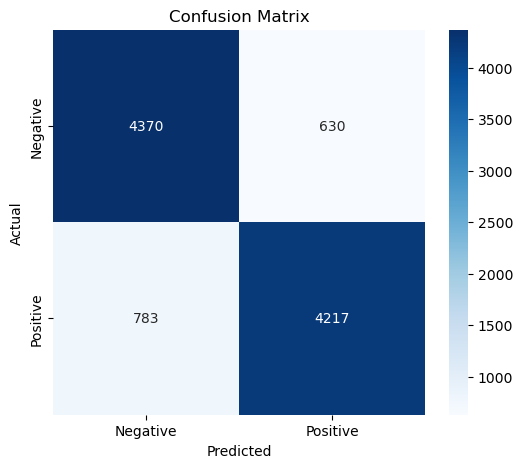


Prediction:
['positive']


In [3]:
import pandas as pd
import nltk
import re
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 1: Download Stopwords
nltk.download('stopwords')

# Step 2: Load Dataset
data = pd.read_csv("IMDB Dataset.csv")

print(data.head())

# Step 3: Stopwords and Stemmer
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

# Step 4: Text Preprocessing
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.split()

    words = [stemmer.stem(word)
             for word in text
             if word not in stop_words]

    return " ".join(words)

# Clean the review text
data["Clean_Text"] = data["review"].apply(preprocess)

print(data[["review", "Clean_Text"]].head())

# Step 5: Feature Extraction using TF-IDF
tfidf = TfidfVectorizer()

X = tfidf.fit_transform(data["Clean_Text"])

y = data["sentiment"]

# Step 6: Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Step 7: Train Naive Bayes Model
model = MultinomialNB()

model.fit(X_train, y_train)

# Step 8: Test Model
prediction = model.predict(X_test)

print("\nPredictions:")
print(prediction)

# Accuracy
print("\nAccuracy:")
print(accuracy_score(y_test, prediction))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, prediction))

# Step 9: Confusion Matrix
cm = confusion_matrix(y_test, prediction)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=["Negative","Positive"],
            yticklabels=["Negative","Positive"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Step 10: Predict New Review
new_review = [
    "The movie was absolutely amazing and I loved every scene."
]

new_review = [preprocess(review) for review in new_review]

new_text = tfidf.transform(new_review)

result = model.predict(new_text)

print("\nPrediction:")
print(result)

In [2]:
print(data.columns)

Index(['review', 'sentiment'], dtype='object')


In [4]:
print(data["Sentiment"].value_counts())

Sentiment
Positive    5898
Neutral      772
Negative     467
Name: count, dtype: int64
